# Análisis de Absentismo Laboral - RHHH

### Preguntas de negocio

> ¿Cuál es la magnitud del absentismo laboral en la empresa y cómo varía a lo largo del año?  
> ¿Cómo podemos anticiparnos para reforzar la planificación de recursos humanos y garantizar la continuidad operativa?

---
## 1. Import y carga

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats


In [2]:
CSV_PATH = r'..\Data\DatasetClean_2026-06-29.csv'

df = pd.read_csv(CSV_PATH)


 Excluímos del análisis solicitudes de absencia si Absenteeism_Hours = 0
 > Nota: el 90,7% de los registros con Absenteeism_Hours = 0 corresponden a  Disciplinary_Failure = 1 (39 de 43 casos).

In [3]:
n_antes = len(df)
df = df[df["Absenteeism_Hours"] != 0].copy()
n_despues = len(df)

print(f'Registros antes del filtro: {n_antes}')
print(f'Registros después del filtro: {n_despues}')
print(f'Registros omitidos: {n_antes - n_despues}')

Registros antes del filtro: 705
Registros después del filtro: 662
Registros omitidos: 43


In [ ]:
# Dict para visualizaciones
MESOS = {0: 'Sin mes', 1: 'Ene', 2: 'Feb', 3: 'Mar', 4: 'Abr', 5: 'May', 6: 'Jun', 7: 'Jul', 8: 'Ago', 9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Dic'}

df['Month_Absence_Desc'] = df['Month_Absence'].map(MESOS)

---
## 2.Magnitud del absentismo

In [5]:
print('Estadística descriptiva de Absenteeism_Hours')
print(df["Absenteeism_Hours"].describe().round(2))
print(f'\nAsimetría (skewness): {df["Absenteeism_Hours"].skew():.2f}')
print(f'\nHoras totales de absentismo:   {df["Absenteeism_Hours"].sum():.0f} h')
print(f'Media por absencia:            {df["Absenteeism_Hours"].mean():.1f} h')
print(f'Mediana por absencia:          {df["Absenteeism_Hours"].median():.1f} h')


Estadística descriptiva de Absenteeism_Hours
count    662.00
mean       7.62
std       13.92
min        1.00
25%        2.00
50%        4.00
75%        8.00
max      120.00
Name: Absenteeism_Hours, dtype: float64

Asimetría (skewness): 5.47

Horas totales de absentismo:   5043 h
Media por absencia:            7.6 h
Mediana por absencia:          4.0 h


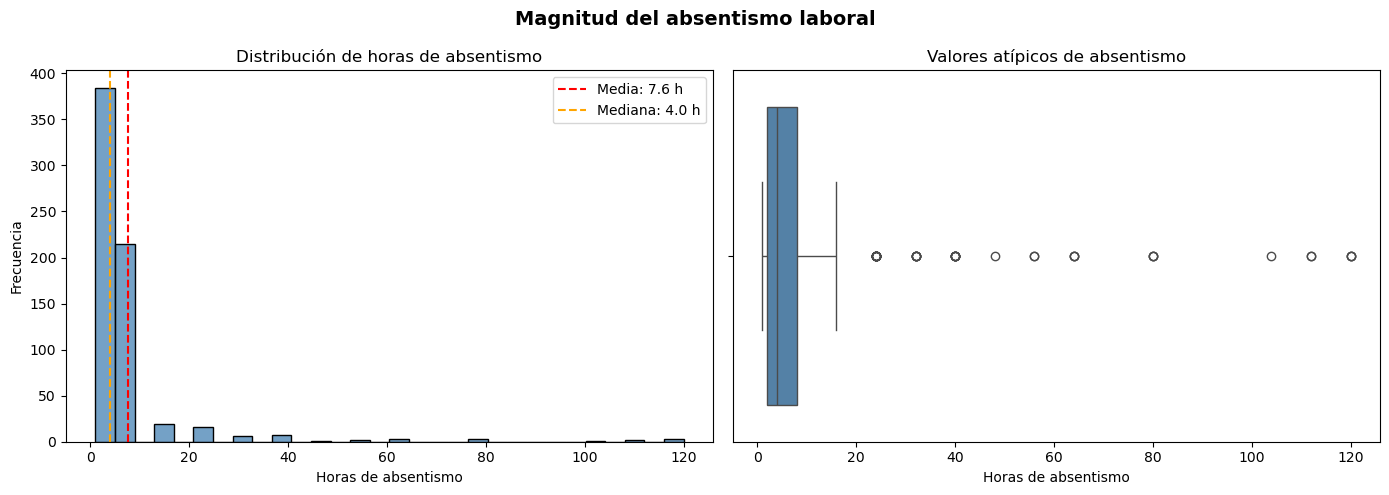

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df["Absenteeism_Hours"], bins=30, ax=axes[0], color='steelblue')
axes[0].axvline(df["Absenteeism_Hours"].mean(), color='red', linestyle='--', linewidth=1.5,
                label=f'Media: {df["Absenteeism_Hours"].mean():.1f} h')
axes[0].axvline(df["Absenteeism_Hours"].median(), color='orange', linestyle='--', linewidth=1.5,
                label=f'Mediana: {df["Absenteeism_Hours"].median():.1f} h')
axes[0].set_title('Distribución de horas de absentismo')
axes[0].set_xlabel('Horas de absentismo')
axes[0].set_ylabel('Frecuencia')
axes[0].legend()

sns.boxplot(x=df["Absenteeism_Hours"], ax=axes[1], color='steelblue')
axes[1].set_title('Valores atípicos de absentismo')
axes[1].set_xlabel('Horas de absentismo')

plt.suptitle('Magnitud del absentismo laboral', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()



In [7]:
# Horas totales por empleado
abs_per_empleat = df.groupby('ID_Employee')["Absenteeism_Hours"].agg(
    total_horas='sum',
    num_absencias='count',
    mediana_horas='median'
).round(1).sort_values('total_horas', ascending=False)


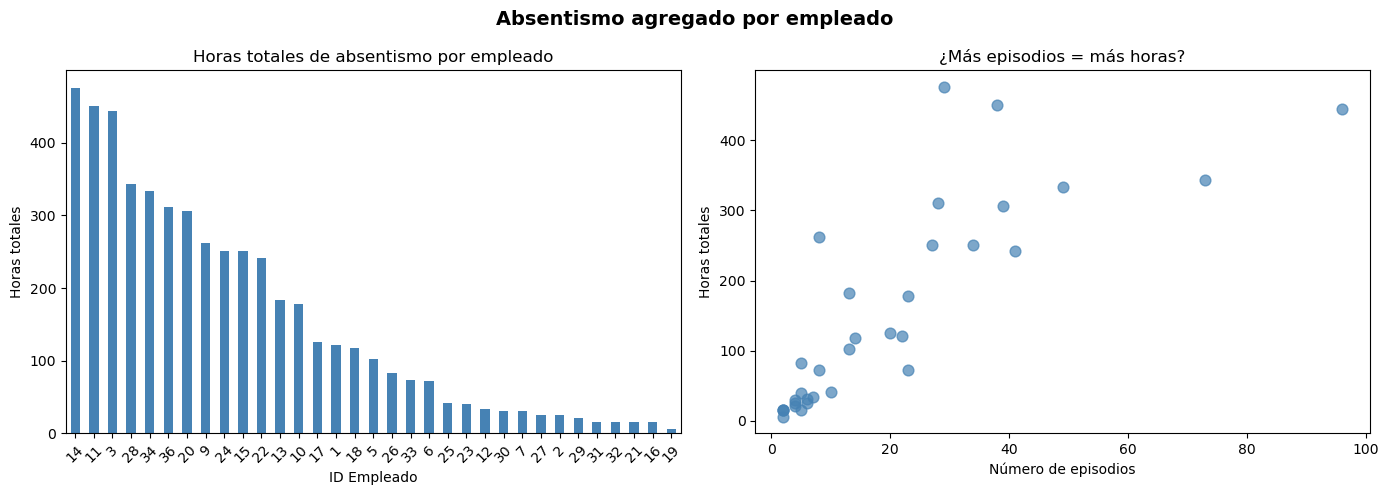

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

abs_per_empleat['total_horas'].plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Horas totales de absentismo por empleado')
axes[0].set_xlabel('ID Empleado')
axes[0].set_ylabel('Horas totales')
axes[0].tick_params(axis='x', rotation=45)

axes[1].scatter(abs_per_empleat['num_absencias'], abs_per_empleat['total_horas'],
                alpha=0.7, color='steelblue', s=60)
axes[1].set_title('¿Más episodios = más horas?')
axes[1].set_xlabel('Número de episodios')
axes[1].set_ylabel('Horas totales')

plt.suptitle('Absentismo agregado por empleado', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---

## 3. Variación anual

**suma** de horas para ver el impacto total en la empresa, **mediana** para ver la magnitud de cada absencia.

**Nota**: se han excluido los registros con `Month_Absence = 0`.

In [9]:
df_mesos = df[df['Month_Absence'] != 0].copy()

---
#### Absentismo por mes

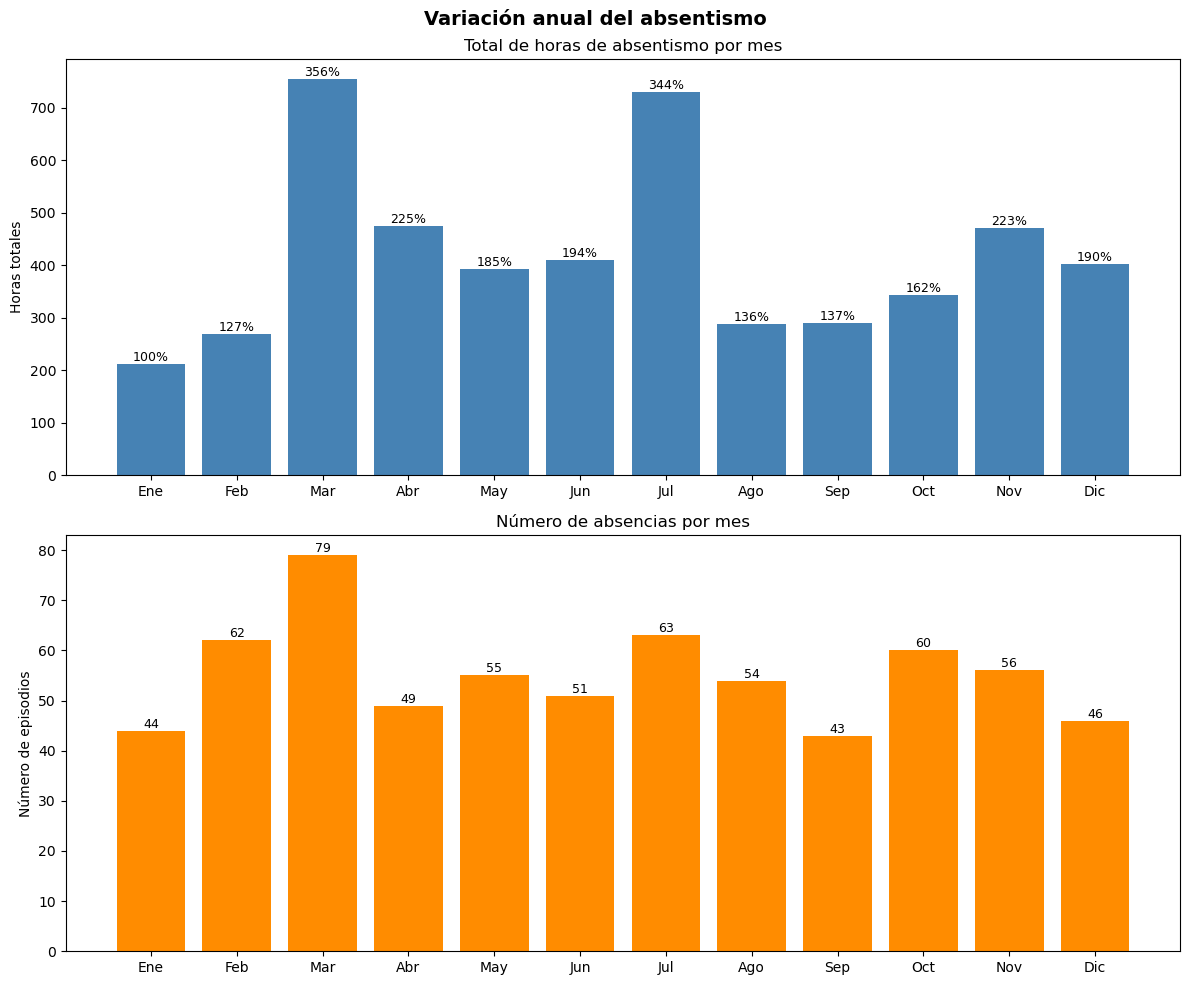

In [10]:
# Absentismo por mes
ordre_mesos = [MESOS[m] for m in range(1, 13)]

abs_mes = df_mesos.groupby('Month_Absence_Desc')["Absenteeism_Hours"].agg(
    total_horas='sum',
    num_absencias='count',
    mediana_horas='median'
).reindex(ordre_mesos).reset_index()

fig, axes = plt.subplots(2, 1, figsize=(12, 10))

bars = axes[0].bar(abs_mes['Month_Absence_Desc'], abs_mes['total_horas'], color='steelblue')

# Calculamos el % de cada mes respecto al mes con menos horas
mes_min_horas = abs_mes['total_horas'].min()
etiquetas_pct = [f'{(v / mes_min_horas * 100):.0f}%' for v in abs_mes['total_horas']]
axes[0].bar_label(bars, labels=etiquetas_pct, fontsize=9)

axes[0].set_title('Total de horas de absentismo por mes')
axes[0].set_ylabel('Horas totales')

bars2 = axes[1].bar(abs_mes['Month_Absence_Desc'], abs_mes['num_absencias'], color='darkorange')
axes[1].bar_label(bars2, fontsize=9)
axes[1].set_title('Número de absencias por mes')
axes[1].set_ylabel('Número de episodios')

plt.suptitle('Variación anual del absentismo', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

TOTAL HORAS:
- Meses con + horas con absencias: Marzo y Julio
- Meses con - horas con absencias: Enero y Febrero

El patrón de absentismo es claramente estacional:
- 2 picos marcados en marzo y julio
- comparado con los meses valle enero , tienen la mitad de episodios y 1 cuarta parte de las horas del mes pico (marzo).

---
#### Meses pico por horas totals absentismo

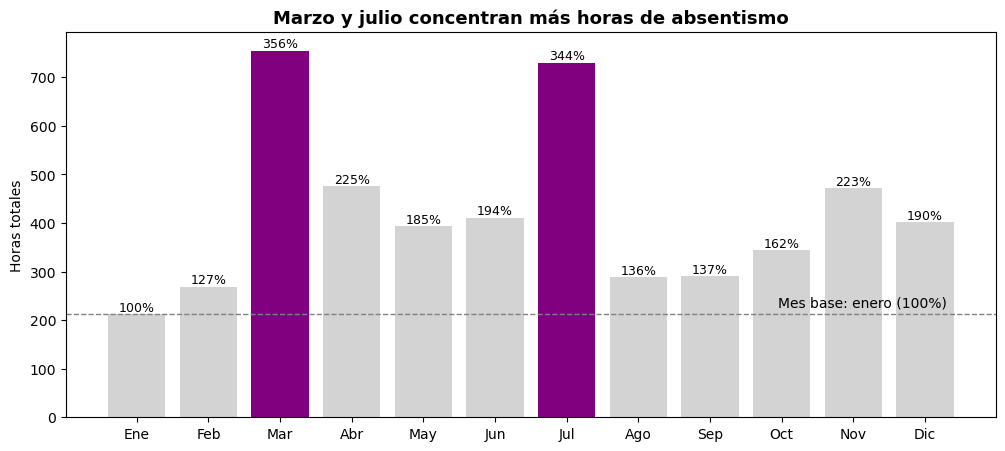

In [11]:
mes_min_horas = abs_mes['total_horas'].min()
etiquetas_pct = [f'{(v / mes_min_horas * 100):.0f}%' for v in abs_mes['total_horas']]
colors = ['purple' if mes in ['Mar', 'Jul'] else 'lightgray' for mes in abs_mes['Month_Absence_Desc']]

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(abs_mes['Month_Absence_Desc'], abs_mes['total_horas'], color=colors)
ax.bar_label(bars, labels=etiquetas_pct, fontsize=9)

# Línea de referencia: el mes mínimo (Enero)
ax.axhline(mes_min_horas, color='gray', linestyle='--', linewidth=1)
ax.text(11.3, mes_min_horas + 15, 'Mes base: enero (100%)', fontsize=10, color='black', ha='right')

ax.set_title('Marzo y julio concentran más horas de absentismo', fontsize=13, fontweight='bold')
ax.set_ylabel('Horas totales')

plt.show()

---
#### Variación horas acumuladas vs total absencias respecto a un mes típico

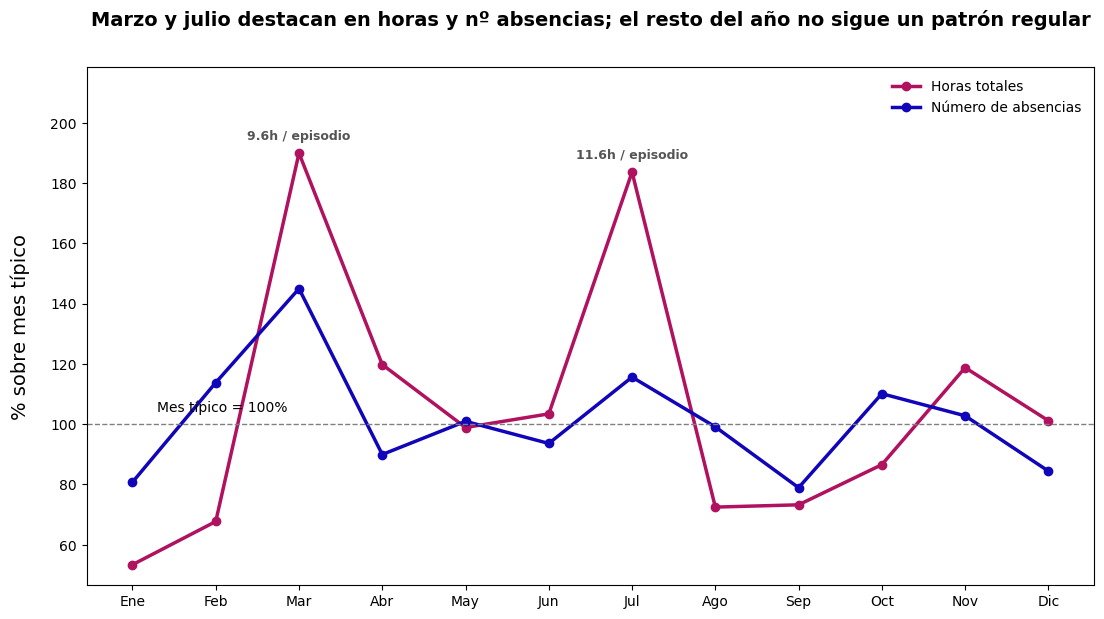

In [12]:
ordre_mesos = [MESOS[m] for m in range(1, 13)]
abs_mes = df_mesos.groupby('Month_Absence_Desc')["Absenteeism_Hours"].agg(
    total_horas='sum',
    num_absencias='count',
    mediana_horas='median'
).reindex(ordre_mesos).reset_index()

abs_mes['duracio_mitjana'] = (abs_mes['total_horas'] / abs_mes['num_absencias']).round(1)

horas_mediana = abs_mes['total_horas'].median()
episodios_mediana = abs_mes['num_absencias'].median()

pct_horas = abs_mes['total_horas'] / horas_mediana * 100
pct_episodios = abs_mes['num_absencias'] / episodios_mediana * 100

color_horas = '#B0125F'
color_ep = '#1105BA'

fig, ax = plt.subplots(figsize=(13, 7))

ax.plot(abs_mes['Month_Absence_Desc'], pct_horas, color=color_horas,
        marker='o', linewidth=2.5, markersize=6, label='Horas totales')
ax.plot(abs_mes['Month_Absence_Desc'], pct_episodios, color=color_ep,
        marker='o', linewidth=2.5, markersize=6, label='Número de absencias')

ax.axhline(100, color='gray', linestyle='--', linewidth=1)
ax.text(0.3, 104, 'Mes típico = 100%', fontsize=10, color='black')

for mes in ['Mar', 'Jul']:
    i = abs_mes[abs_mes['Month_Absence_Desc'] == mes].index[0]
    duracion = abs_mes['duracio_mitjana'][i]
    y_max = max(pct_horas[i], pct_episodios[i])
    ax.annotate(f'{duracion}h / episodio', (mes, y_max), xytext=(0, 10),
                textcoords='offset points', ha='center', fontsize=9,
                color='#555555', fontweight='bold')

ax.set_ylabel('% sobre mes típico', fontsize=14, labelpad=15)
ax.set_ylim(top=pct_horas.max() * 1.15)
ax.legend(loc='upper right', frameon=False)

plt.title('Marzo y julio destacan en horas y nº absencias; el resto del año no sigue un patrón regular',
          fontsize=14, fontweight='bold', pad=30)
plt.subplots_adjust(top=0.85)
plt.show()

> Coinciden en los dos picos (Mar, Jul); fuera de ellos, el patrón es más irregular

---
#### Total de absencias vs. duración por mes

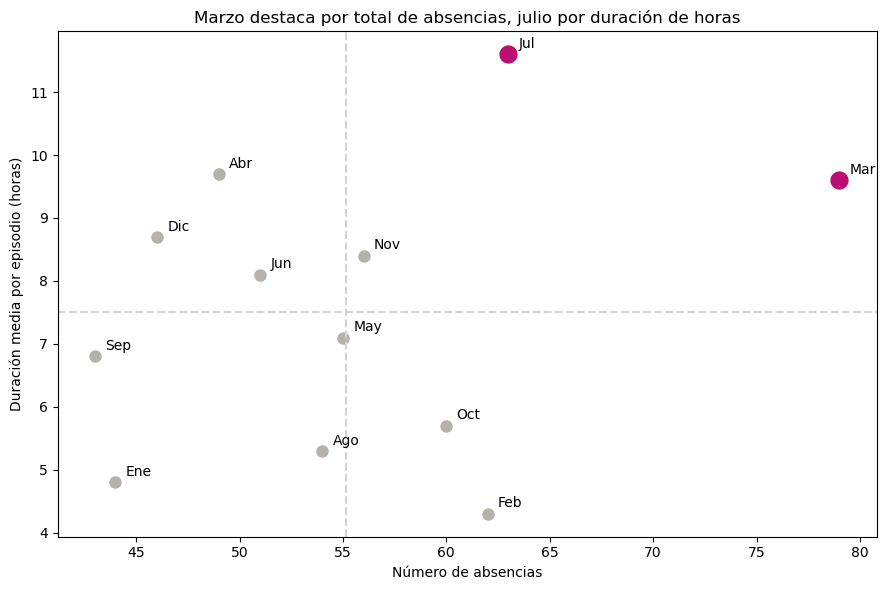

In [13]:
fig, ax = plt.subplots(figsize=(9, 6))

meses_destacar = ['Mar', 'Jul']

# Dibujamos un punto por cada mes, uno a uno
for i in range(len(abs_mes)):
    mes = abs_mes['Month_Absence_Desc'][i]
    x = abs_mes['num_absencias'][i]
    y = abs_mes['duracio_mitjana'][i]

    if mes in meses_destacar:
        color = '#BC0E70'
        tamano = 200
    else:
        color = '#B4B2A9'
        tamano = 100

    ax.scatter(x, y, color=color, s=tamano, edgecolors='white', linewidth=1)
    ax.text(x + 0.5, y + 0.1, mes, fontsize=10)

# Líneas de referencia (medias generales)
media_episodios = abs_mes['num_absencias'].mean()
media_duracion = abs_mes['duracio_mitjana'].mean()
ax.axvline(media_episodios, color='lightgray', linestyle='--')
ax.axhline(media_duracion, color='lightgray', linestyle='--')

ax.set_xlabel('Número de absencias')
ax.set_ylabel('Duración media por episodio (horas)')
ax.set_title('Marzo destaca por total de absencias, julio por duración de horas')

plt.tight_layout()
plt.show()

---
#### Absentismo por día de la semana

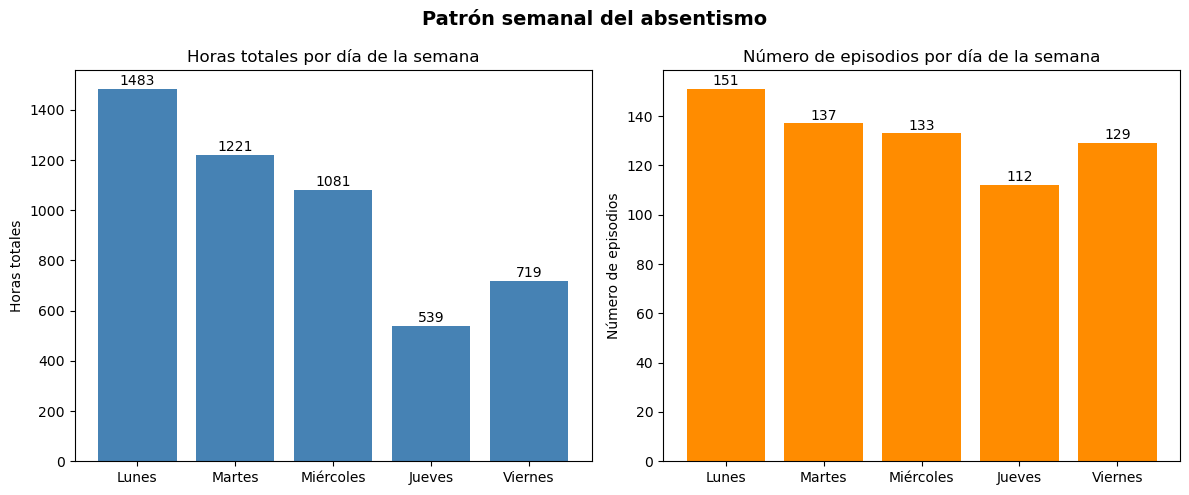

In [14]:

ordre_dies = ['Lunes', 'Martes', 'Miércoles', 'Jueves', 'Viernes']

abs_dia = df.groupby('Day_Week_Desc')["Absenteeism_Hours"].agg(
    total_horas='sum',
    num_absencias='count',
    mediana_horas='median'
).reset_index()

# Reordenar según día de la semana
ordre_reals = [d for d in ordre_dies if d in abs_dia['Day_Week_Desc'].values]
abs_dia = abs_dia.set_index('Day_Week_Desc').reindex(ordre_reals).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

bars = axes[0].bar(abs_dia['Day_Week_Desc'], abs_dia['total_horas'], color='steelblue')
for bar, val in zip(bars, abs_dia['total_horas']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
                 str(int(val)), ha='center', va='bottom', fontsize=10)
axes[0].set_title('Horas totales por día de la semana')
axes[0].set_ylabel('Horas totales')

bars2 = axes[1].bar(abs_dia['Day_Week_Desc'], abs_dia['num_absencias'], color='darkorange')
for bar, val in zip(bars2, abs_dia['num_absencias']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 str(int(val)), ha='center', va='bottom', fontsize=10)
axes[1].set_title('Número de episodios por día de la semana')
axes[1].set_ylabel('Número de episodios')

plt.suptitle('Patrón semanal del absentismo', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Resultados: mismo patrón semanal en total de absencias y total de horas. Pico al inicio de la semana, desciende hasta el mínimo el jueves y vuelve a subir ligeramente.

---
#### Heatmap: mes x día de la semana
¿Combinaciones de mes-día críticas?

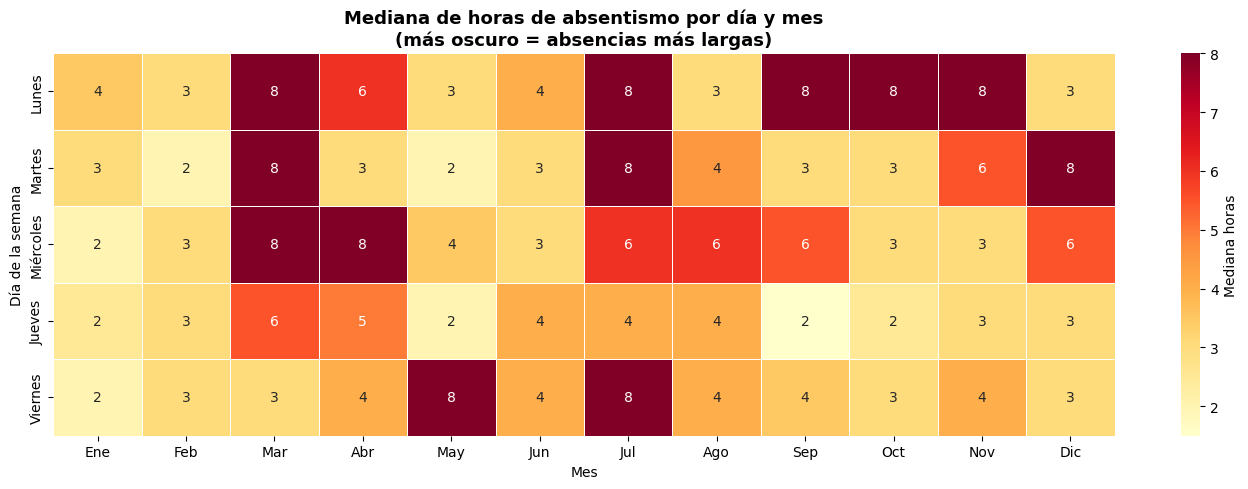

In [15]:
pivot = df_mesos.pivot_table(
    values="Absenteeism_Hours",
    index='Day_Week_Desc',
    columns='Month_Absence_Desc',
    aggfunc='median'
)

ordre_dies_pivot = [d for d in ordre_dies if d in pivot.index]
pivot = pivot.reindex(index=ordre_dies_pivot,
                      columns=[m for m in ordre_mesos if m in pivot.columns])

plt.figure(figsize=(14, 5))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='YlOrRd',
            linewidths=0.5, cbar_kws={'label': 'Mediana horas'})
plt.title('Mediana de horas de absentismo por día y mes\n(más oscuro = absencias más largas)',
          fontsize=13, fontweight='bold')
plt.xlabel('Mes')
plt.ylabel('Día de la semana')
plt.tight_layout()
plt.show()

---
## 4. Análisis por motivo

tres grupos:

- **Enfermedad diagnosticada (ICD 1-21):** enfermedades según la clasificación internacional. Difíciles de anticipar / prevenir desde RRHH.
- **Atención sanitaria programada y otros (ICD 22-25, 27-28):** consultas médicas, fisioterapia, laboratorio, donación de sangre, etc. Sí son planificables por la antelación extra.
- **Ausencia injustificada (ICD 26):** de naturaleza distinta, no sanitaria — se trata por separado.

In [16]:
# Clasificación motivos
def classify_group(codi):
    if codi == 0:
        return 'Sin código'
    elif codi <= 21:
        return 'Enfermedad diagnosticada (ICD 1-21)'
    elif codi == 26:
        return 'Ausencia injustificada'
    else:
        return 'Atención sanitaria programada y otros (ICD 22-28)'


In [17]:
df['reason_group'] = df['Reason_Absence'].apply(classify_group)

---
### Tabla horas según motivo

In [18]:

abs_motiu = df.groupby(['Reason_Absence', 'Reason_Absence_Desc', 'reason_group'])["Absenteeism_Hours"].agg(
    total_horas='sum',
    num_absencias='count',
    mediana_horas='median'
).reset_index().sort_values('total_horas', ascending=False)

print('Top motivos por horas totales')
print()
print(abs_motiu[['Reason_Absence_Desc', 'reason_group', 'total_horas', 'num_absencias', 'mediana_horas']].to_string(index=False))

Top motivos por horas totales

                                 Reason_Absence_Desc                                      reason_group  total_horas  num_absencias  mediana_horas
         Enfermedades del sistema musculoesquelético               Enfermedad diagnosticada (ICD 1-21)          842             55            8.0
                          Lesiones y envenenamientos               Enfermedad diagnosticada (ICD 1-21)          729             40            8.0
                                     Consulta médica Atención sanitaria programada y otros (ICD 22-28)          408            142            2.0
                                     Consulta dental Atención sanitaria programada y otros (ICD 22-28)          329            108            2.0
                  Enfermedades del sistema digestivo               Enfermedad diagnosticada (ICD 1-21)          297             26            8.0
                             Seguimiento de paciente Atención sanitaria programada y otros (I

### Gráfico horas según motivo

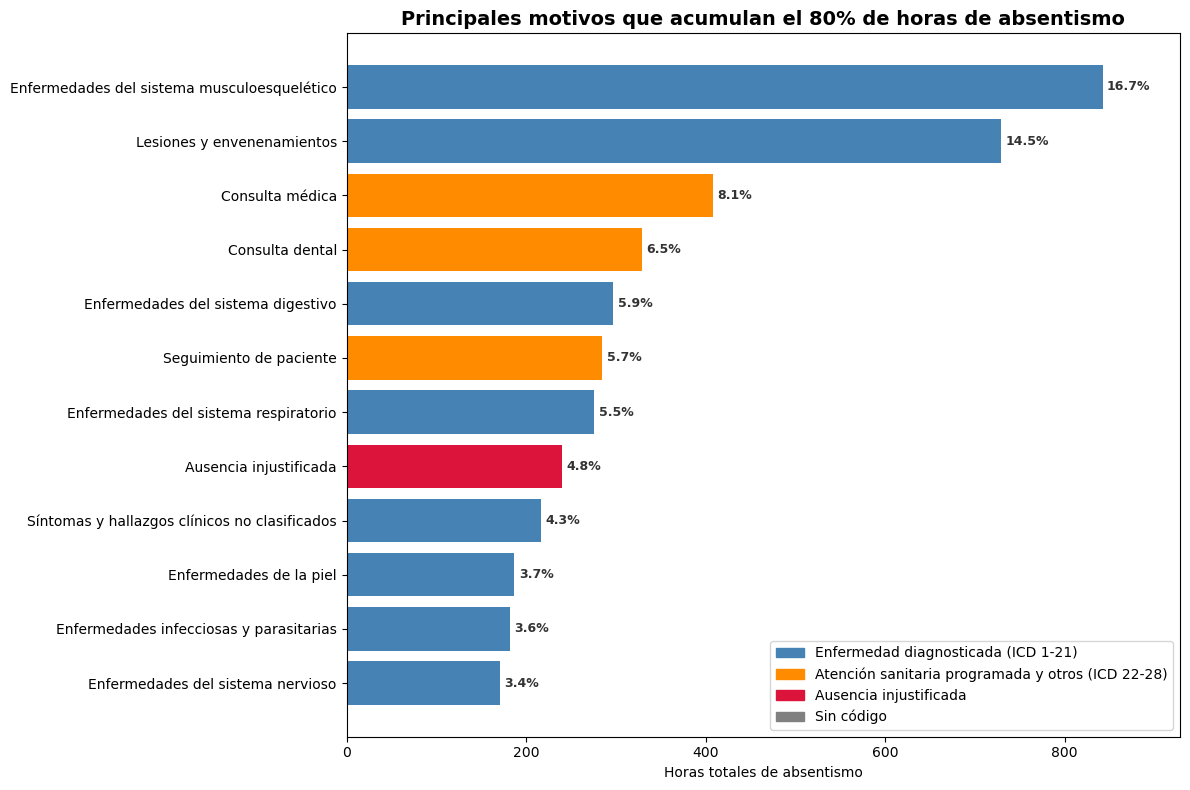

In [19]:
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt

# orden para % acumulado
abs_motiu = abs_motiu.sort_values(by='total_horas', ascending=False)
total_hores_global = abs_motiu['total_horas'].sum()

# Calculo proporción acumulada
abs_motiu['pct_acumulat'] = (
    abs_motiu['total_horas'].cumsum() / total_hores_global
) * 100

# Filtro motivos dentro 80%
motius_top_80 = abs_motiu[
    abs_motiu['pct_acumulat'].shift(1).fillna(0) <= 80
].copy()

# Gráfico con df filtrado
color_map = {
    'Enfermedad diagnosticada (ICD 1-21)': 'steelblue',
    'Atención sanitaria programada y otros (ICD 22-28)': 'darkorange',
    'Ausencia injustificada': 'crimson',
    'Sin código': 'grey',
}
colors = motius_top_80['reason_group'].map(color_map)

plt.figure(figsize=(12, 8))
bars = plt.barh(
    motius_top_80['Reason_Absence_Desc'],
    motius_top_80['total_horas'],
    color=colors,
)

for bar in bars:
    width = bar.get_width()
    if width > 0:
        pct = (width / total_hores_global) * 100
        plt.text(
            width + 5,
            bar.get_y() + bar.get_height() / 2,
            f'{pct:.1f}%',
            va='center',
            ha='left',
            fontsize=9,
            fontweight='bold',
            color='#333333',
        )

plt.xlabel('Horas totales de absentismo')
plt.title(
    'Principales motivos que acumulan el 80% de horas de absentismo',
    fontsize=14,
    fontweight='bold',
)
plt.gca().invert_yaxis()

plt.xlim(right=plt.gca().get_xlim()[1] * 1.05)

llegenda = [mpatches.Patch(color=v, label=k) for k, v in color_map.items()]
plt.legend(handles=llegenda, loc='lower right')
plt.tight_layout()
plt.show()

> 12 de los 27 motivos acumulan el 80% de las horas acumulada
    - Bajas por enfermedad: 55%
    - Motivos programables: 20%
    - Motivos injustificados: 5%

---
### Proporción enfermedades médicas ICD vs otros

 Proporción por tipo de motivo (horas totales) 
                                     reason_group  total_horas  pct
Atención sanitaria programada y otros (ICD 22-28)         1260 25.0
                           Ausencia injustificada          240  4.8
              Enfermedad diagnosticada (ICD 1-21)         3543 70.3


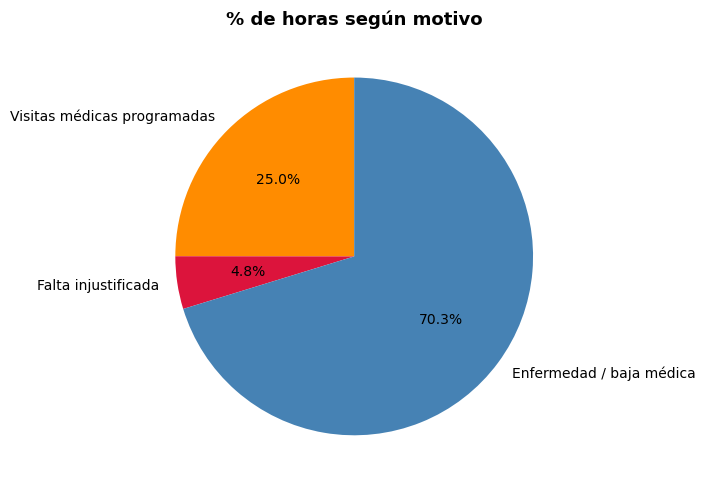

In [20]:

resum = abs_motiu.groupby('reason_group')['total_horas'].sum().reset_index()
resum['pct'] = (resum['total_horas'] / resum['total_horas'].sum() * 100).round(1)

print(' Proporción por tipo de motivo (horas totales) ')
print(resum.to_string(index=False))

label_translation = {
    'Enfermedad diagnosticada (ICD 1-21)': 'Enfermedad / baja médica',
    'Atención sanitaria programada y otros (ICD 22-28)': 'Visitas médicas programadas',
    'Ausencia injustificada': 'Falta injustificada',
    'Sin código': 'Sin especificar',
}

new_labels_pie = [
    label_translation.get(motiu, motiu) for motiu in resum['reason_group']
]

plt.figure(figsize=(7, 5))
plt.pie(resum['total_horas'],
        labels=new_labels_pie,
        autopct='%1.1f%%',
        colors=[color_map.get(t, 'grey') for t in resum['reason_group']],
        startangle=90)
plt.title('% de horas según motivo', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Heatmap de motivos planificables por mes (atención sanitaria programada)

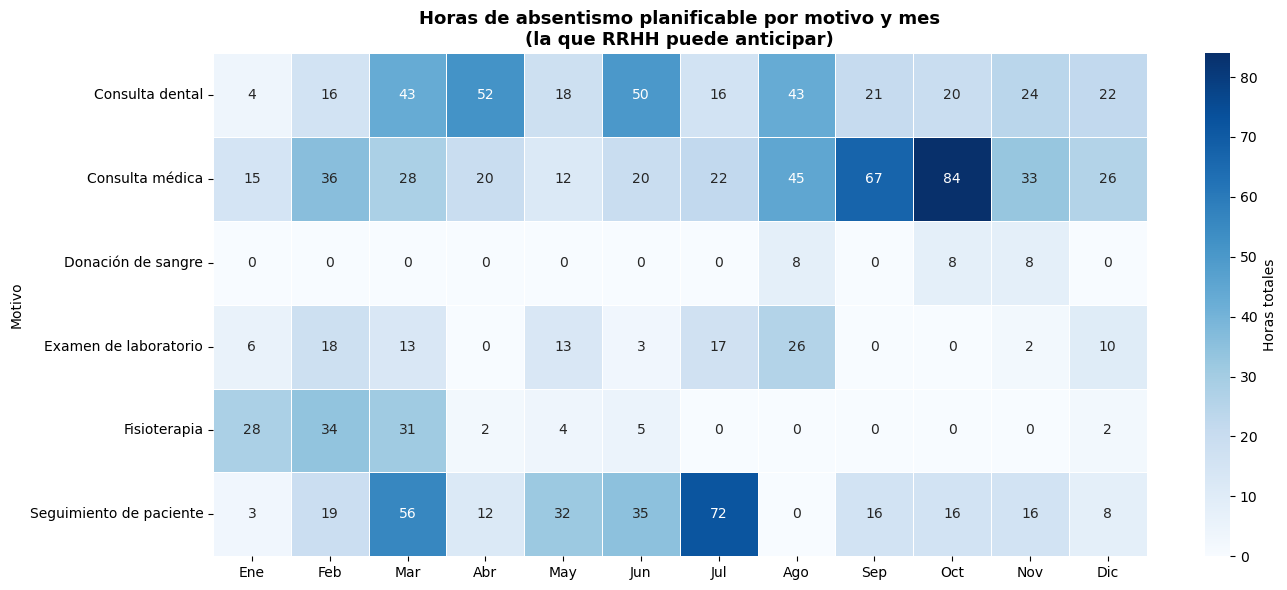

In [21]:

df_planificable = df_mesos[(df_mesos['Reason_Absence'] >= 22) & (df_mesos['Reason_Absence'] != 26)].copy()

pivot_nm = df_planificable.pivot_table(
    values="Absenteeism_Hours",
    index='Reason_Absence_Desc',
    columns='Month_Absence_Desc',
    aggfunc='sum',
    fill_value=0
)
pivot_nm = pivot_nm[[m for m in ordre_mesos if m in pivot_nm.columns]]

plt.figure(figsize=(14, 6))
sns.heatmap(pivot_nm, annot=True, fmt='g', cmap='Blues',
            linewidths=0.5, cbar_kws={'label': 'Horas totales'})
plt.title('Horas de absentismo planificable por motivo y mes\n(la que RRHH puede anticipar)',
          fontsize=13, fontweight='bold')
plt.xlabel('')
plt.ylabel('Motivo')
plt.tight_layout()
plt.show()

---
## 6. Conclusiones y recomendaciones de negocio

In [22]:
abs_estacio = df.groupby('Season_Desc')["Absenteeism_Hours"].agg(
    total_horas='sum',
    num_absencias='count',
    mediana_horas='median'
).reset_index()

In [ ]:
total_horas = df['Absenteeism_Hours'].sum()
mediana_ep = df['Absenteeism_Hours'].median()
num_empleats = df['ID_Employee'].nunique()
hores_per_emp = total_horas / num_empleats

mes_max = abs_mes.loc[abs_mes['total_horas'].idxmax(), 'Month_Absence_Desc']
mes_min = abs_mes.loc[abs_mes['total_horas'].idxmin(), 'Month_Absence_Desc']
dia_max_ep = abs_dia.loc[abs_dia['num_absencias'].idxmax(), 'Day_Week_Desc']
motiu_top = abs_motiu.iloc[0]['Reason_Absence_Desc']

print('--- RESUMEN EJECUTIVO ---')
print('Total horas:', total_horas)
print('Mediana por caso:', mediana_ep)
print('Media de horas por empleado:', round(hores_per_emp, 1))
print('Mes máximo:', mes_max, '| Mes mínimo:', mes_min)
print('Día con más incidencias:', dia_max_ep)
print('Motivo principal:', motiu_top)

--- RESUMEN EJECUTIVO ---
Total horas: 5043
Mediana por caso: 4.0
Media de horas por empleado: 152.8
Mes máximo: Mar | Mes mínimo: Ene
Día con más incidencias: Lunes
Motivo principal: Enfermedades del sistema musculoesquelético


In [24]:
def generar_calendario_generico(pivot):
    """
    Genera una tabla con todas las combinaciones de mes y día laborable,
    indicando el nivel de absentismo previsto según el patrón histórico.
    Parámetros:
        pivot (DataFrame): tabla mes x día con la mediana de horas (heatmap)
    Return:
        DataFrame: una fila por combinación mes-día, con sus horas previstas
    """
    dias_laborables = ['Lunes', 'Martes', 'Miércoles', 'Jueves', 'Viernes']
    filas = []

    for mes in pivot.columns:
        for dia in dias_laborables:
            if dia in pivot.index:
                horas = pivot.loc[dia, mes]
                filas.append({
                    'Mes': mes,
                    'Día_semana': dia,
                    'Horas_previstas': horas
                })

    return pd.DataFrame(filas)

def clasificar_riesgo_dia(horas, mediana_general):
    """
    Clasifica el riesgo de un día concreto comparándolo con la mediana general.
    Parámetros:
        horas (float): horas previstas para ese día
        mediana_general (float): mediana de todas las combinaciones mes-día
    Return: str: 'Alto', 'Medio' o 'Bajo'
    """
    if horas >= mediana_general * 1.5:
        return 'Alto'
    elif horas >= mediana_general:
        return 'Medio'
    else:
        return 'Bajo'



In [25]:
calendario_generico = generar_calendario_generico(pivot)
mediana_general = calendario_generico['Horas_previstas'].median()
calendario_generico['Riesgo'] = calendario_generico['Horas_previstas'].apply(lambda h: clasificar_riesgo_dia(h, mediana_general))

print(calendario_generico.sort_values('Horas_previstas', ascending=False).to_string(index=False))


Mes Día_semana  Horas_previstas Riesgo
Jul      Lunes              8.0   Alto
Sep      Lunes              8.0   Alto
Dic     Martes              8.0   Alto
May    Viernes              8.0   Alto
Jul    Viernes              8.0   Alto
Nov      Lunes              8.0   Alto
Oct      Lunes              8.0   Alto
Abr  Miércoles              8.0   Alto
Mar      Lunes              8.0   Alto
Mar     Martes              8.0   Alto
Mar  Miércoles              8.0   Alto
Jul     Martes              8.0   Alto
Jul  Miércoles              6.0   Alto
Ago  Miércoles              6.0   Alto
Abr      Lunes              6.0   Alto
Mar     Jueves              5.5   Alto
Sep  Miércoles              5.5   Alto
Nov     Martes              5.5   Alto
Dic  Miércoles              5.5   Alto
Abr     Jueves              5.0  Medio
Ago     Martes              4.5  Medio
Ago    Viernes              4.0  Medio
Abr    Viernes              4.0  Medio
Ago     Jueves              4.0  Medio
Nov    Viernes           

---
## Conclusiones y Respuestas a las Preguntas de Negocio

### Pregunta 1: ¿Cuál es la magnitud del absentismo laboral en la empresa y cómo varía a lo largo del año?

**Magnitud**

- Total de **5.043 horas** perdidas por absentismo en el periodo analizado, repartidas en 662 episodios.
- La duración típica de un episodio es de **4,0 horas (mediana)**. Existen casos excepcionales que llegan hasta las **120 horas**.
- 5.043h equivalen aproximadamente a la jornada anual completa (~1.790h/año) de **2,8 personas a tiempo completo**.

**Variación a lo largo del año**

- Clara estacionalidad: los picos críticos ocurren en **marzo (755h, 79 episodios)** y **julio (730h, 63 episodios)**; enero es el mes con menos horas totales (212h, 44 episodios).
- Marzo y julio no son el mismo fenómeno: marzo destaca por **frecuencia** (más episodios), julio por **duración media por episodio (11,6h frente a 9,6h de marzo)**.
- La relación entre horas totales y número de episodios es débil fuera de estos dos meses (correlación de Spearman = 0,434, no significativa, p=0,159). Por ejemplo, **febrero tiene el tercer mayor número de episodios del año (62)** pese a tener horas totales bajas — no se puede asumir que "menos horas" implique siempre "menos episodios".

### Pregunta 2: ¿Cómo podemos anticiparnos para reforzar la planificación de RRHH y garantizar la continuidad operativa?

**Diagnóstico por motivo (la base para las recomendaciones)**

- **70% de las horas** se concentra en enfermedad diagnosticada (ICD 1-21); absentismo no planificable. Factor principal: enfermedades del sistema musculoesquelético (~16%) y lesiones/envenenamientos (~15%).
- **~25% de las horas** corresponde a atención sanitaria programada y otros (ICD 22-28, excluyendo ausencia injustificada) — potencialmente planificable con antelación.
- **~5% de las horas** corresponde a ausencia injustificada (ICD 26).
- Marzo y julio concentran, específicamente, más bajas médicas (ICD 1-21) que el resto del año.

**Recomendaciones**

*Herramientas de anticipación:*
1. Calendario mensual (mes × día de la semana) con los niveles de intensidad de absentismo histórica, como apoyo a la planificación.
2. Solicitar el registro del día de inicio y fin de cada ausencia para mejorar la granularidad de futuros análisis predictivos.

*Minimizar el impacto operativo en los picos:*
1. Establecer acuerdos preventivos con empresas de trabajo temporal (ETT), activados con antelación en **febrero y junio, de cara a reforzar marzo y julio**, dado que son los meses de mayor impacto detectado.

*Reducir el absentismo por enfermedad (motivo principal, no planificable):*
1. Talleres de higiene postural y prevención de riesgos laborales, dado que los trastornos musculoesqueléticos son el motivo individual con más horas.
2. Valorar una partida presupuestaria para fisioterapia preventiva u otras acciones de bienestar físico dirigidas a este motivo concreto.
3. Explorar el cruce con variables sociodemográficas disponibles en el dataset (edad, número de hijos, malos hábitos, etc.) para identificar perfiles de mayor riesgo y adaptar la distribución interna de tareas.

*Reducir el impacto del absentismo planificable:*
1. Campaña interna para incentivar la notificación anticipada de consultas médicas y dentales programadas, ampliando el margen de reacción de RRHH.
